# 31 — Wu 2003 fault classification (posterior-mass approach)

Unsupervised fault classification for the Wu (2003) CSTR-column-recycle plant, using the
same **posterior-mass** methodology as the propylene-oxide system (`nb11`, §6.2 of the
article): assign each posterior sample to a fault-unit region and report the aggregate
class probabilities — no supervised fault labels are used anywhere in this notebook.

**Scope and what this notebook is *not* claiming (read this before the numbers below):**
this notebook classifies which *unit* (reactor / column / feed) is at fault, using the
**calibrated seed-4 S-B posterior** only. Per `HANDOFF.md`/§8.4 L10, the S-A posterior never
achieved calibration (0/40 seeds passed SBC) and is **not used for any quantitative claim**
here. Per the session's final framing (§7.4/§8.1, `HANDOFF.md` Finding 9), the two candidate
*parameter-level* joint degeneracies investigated for this plant — (α, η_col) at W12 and
(α, β_r) at W11 — are now both understood as **artifacts of the summary-statistic
representation**, not genuine physical banana confounds. This notebook is explicitly framed
as a **worked example of that diagnostic** (§8.1): it asks whether the (α, β_r) or
(α, η_col) representation artifacts actually *matter* at the coarser fault-unit
classification granularity used for plant-wide monitoring — a different, and for an
operator arguably more relevant, question than "is the 2-parameter joint posterior
correlated." See §6 below for the W11/W12 worked examples specifically.

**Fault taxonomy** (5 classes, matching the article's §7.3 definition and
`cstr_sbi.recycle.scenarios.FAULT_UNITS`): `healthy`, `reactor` (α↓ or β_r↓), `column`
(η_col↓ or ξ_reb↓), `feed` (z_A0↓), `multi` (more than one unit degraded — "compound" in
the article text).

## 1. Setup

In [1]:
import sys; sys.path.insert(0, '../src')
import pathlib
import pickle
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from cstr_sbi.recycle.scenarios import list_closed_loop, FAULT_UNITS
from cstr_sbi.recycle.simulator import nominal_warm_start, deterministic_window, noisy_replicates
from cstr_sbi.recycle.summaries import compute_summaries
from cstr_sbi.recycle.physics import PARAM_NAMES

torch.manual_seed(20260705)  # reproducible posterior sampling across reruns

ROOT     = pathlib.Path.cwd().parent
SBI_LOGS = ROOT / 'sbi-logs'
FIGURES  = ROOT / 'figures'; FIGURES.mkdir(exist_ok=True)
RESULTS  = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)

print("Params:", PARAM_NAMES)
print("Fault units:", FAULT_UNITS)

Params: ['alpha', 'beta_r', 'eta_col', 'xi_reb', 'z_A0_eff']
Fault units: ['healthy', 'reactor', 'column', 'feed', 'multi']


In [2]:
with open(SBI_LOGS / 'wu2003_posterior_sb.pkl', 'rb') as f:
    sb_data = pickle.load(f)
posterior_sb = sb_data['posterior']
print(f"Loaded S-B posterior: seed={sb_data['selected_seed']}, N_TRAIN={sb_data['N_TRAIN']}, "
      f"arch={sb_data['arch']} ({sb_data['hidden_features']}/{sb_data['num_transforms']})")
print(f"Selection: {sb_data['selection_method']}")

# S-A is a settled negative result (0/40 seeds passed SBC, HANDOFF.md L10 / article §8.4) --
# not loaded, not used for any quantitative claim in this notebook.
print("\nS-A posterior intentionally NOT loaded: 0/40 seeds passed SBC (article §8.4 L10). "
      "This notebook reports S-B classification only.")

Loaded S-B posterior: seed=4, N_TRAIN=15000, arch=zuko_nsf (60/3)
Selection: 8-seed ensemble, selected by max(min KS p-value across all 5 params) at N_SBC~400; seed 4 confirmed robust across 3 independent SBC draws at N=200/400/800 (see HANDOFF.md Finding 4/4b)

S-A posterior intentionally NOT loaded: 0/40 seeds passed SBC (article §8.4 L10). This notebook reports S-B classification only.


In [3]:
def sample_posterior_direct(posterior, x_obs, n):
    """Sample the underlying flow directly, bypassing DirectPosterior.sample()'s
    unconditional prior-support rejection (see nb27 §4 / HANDOFF.md API correction --
    sbi 0.24 did not make direct sampling the default; .sample() can hang 0% acceptance
    for observations whose flow mass drifts outside the training prior box)."""
    with torch.no_grad():
        samp = posterior.posterior_estimator.sample((n,), condition=x_obs.reshape(1, -1))
    return samp.reshape(-1, 5).numpy()


y0_sb = nominal_warm_start("S-B")
print("Nominal S-B warm start computed.")

Nominal S-B warm start computed.


## 2. Fault-unit taxonomy and posterior-mass classifier

**Threshold choice.** The propylene-oxide system's classifier (`cstr_sbi.metrics.classify_fault`,
nb11) uses a single domain-informed threshold of **0.85** (nominal 1.0) for both α and β,
chosen to absorb that system's own ~0.10–0.15 structural downward bias. This notebook reuses
the *same* 0.85 relative threshold, applied uniformly to all four degradable parameters
(α, β_r, η_col, ξ_reb — all nominal 1.0) for consistency with the paper's established
convention, rather than inventing a new per-parameter threshold. For `z_A0_eff` (nominal
0.90, not 1.0), the equivalent relative rule is applied one-sided:
`z_A0_eff < 0.85 * 0.90 = 0.765` — one-sided because every feed-fault scenario in this
study's taxonomy is a *lean* feed (impurity), never rich.

A posterior sample is assigned to exactly one of 5 mutually exclusive labels via a
**hierarchical rule** matching `RecycleScenarioConfig.fault_unit()`'s categories:
reactor-bad OR column-bad OR feed-bad, singly → that unit; more than one simultaneously →
`multi`; none → `healthy`. The **reported class** is the posterior-mass mode (highest
fraction of samples), and the **reported confidence** is that fraction — exactly the M6c
convention from nb11/§4.5.

In [4]:
THRESH   = 0.85
Z0_NOM   = 0.90


def sample_fault_unit(theta_row: np.ndarray, thresh: float = THRESH, z0_nom: float = Z0_NOM) -> str:
    alpha, beta_r, eta_col, xi_reb, z_A0 = theta_row
    reactor_bad = (alpha < thresh) or (beta_r < thresh)
    column_bad  = (eta_col < thresh) or (xi_reb < thresh)
    feed_bad    = z_A0 < thresh * z0_nom
    n_bad = int(reactor_bad) + int(column_bad) + int(feed_bad)
    if n_bad == 0:
        return "healthy"
    if n_bad >= 2:
        return "multi"
    if reactor_bad:
        return "reactor"
    if column_bad:
        return "column"
    return "feed"


def classify_fault_recycle(samples: np.ndarray) -> dict:
    """Posterior-mass fault classification from (n_samples, 5) [alpha, beta_r, eta_col,
    xi_reb, z_A0_eff] posterior draws. Mirrors cstr_sbi.metrics.classify_fault (PO system)."""
    labels = [sample_fault_unit(row) for row in samples]
    probs = {u: float(np.mean([l == u for l in labels])) for u in FAULT_UNITS}
    predicted = max(probs, key=probs.__getitem__)
    return {
        "class": predicted,
        "probs": probs,
        "means": {p: float(np.mean(samples[:, i])) for i, p in enumerate(PARAM_NAMES)},
    }


def compute_classification_metrics_recycle(preds: list, trues: list, classes=FAULT_UNITS) -> dict:
    """5-class confusion matrix / per-class F1 / macro-F1, generalising
    cstr_sbi.metrics.compute_classification_metrics (which hardcodes the PO system's 4
    classes) to this plant's 5-unit taxonomy."""
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    c2i = {c: i for i, c in enumerate(classes)}
    for true, pred in zip(trues, preds):
        cm[c2i[true], c2i[pred]] += 1
    f1_per_class = {}
    for i, cls in enumerate(classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_per_class[cls] = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    macro_f1 = float(np.mean(list(f1_per_class.values())))
    accuracy = float(np.diag(cm).sum() / cm.sum()) if cm.sum() > 0 else 0.0
    return {"confusion_matrix": cm, "class_names": classes,
            "per_class_f1": f1_per_class, "macro_f1": macro_f1, "accuracy": accuracy}


print("Classifier defined.")

Classifier defined.


## 3. Snapshot classification — 14 scenarios x 30 replicates

Uses the 14 closed-loop scenarios that survive the QSS-column stability constraint (W8,
W14 excluded — ODE blow-up, see `cstr_sbi.recycle.scenarios`). 30 noisy replicates per
scenario (matching Table 6's Luyben eval-replicate budget), 200 posterior draws per
replicate, sampled with `sample_posterior_direct` (safe against the sbi 0.24
prior-support-rejection hang).

In [5]:
N_REPS = 30
N_POST = 200

results = {}
t0 = time.time()
for sc in list_closed_loop():
    t_h, raw_obs = deterministic_window(sc, structure="S-B", y0=y0_sb)
    t_h_arr = np.asarray(t_h)
    raw_obs = np.asarray(raw_obs)

    rng = np.random.default_rng(20260705)
    reps = noisy_replicates(raw_obs, n_replicates=N_REPS, rng=rng, noise_pct=0.003)

    rep_results = []
    for i in range(N_REPS):
        s = compute_summaries(reps[i], "S-B", t_h_arr)
        if np.isnan(s).any():
            continue
        x_obs = torch.tensor(s, dtype=torch.float32)
        samp = sample_posterior_direct(posterior_sb, x_obs, N_POST)
        rep_results.append(classify_fault_recycle(samp))

    # Pooled posterior across all replicates -- used for the scenario-level worked examples
    all_samp = np.concatenate([
        sample_posterior_direct(
            posterior_sb,
            torch.tensor(compute_summaries(reps[i], "S-B", t_h_arr), dtype=torch.float32),
            N_POST,
        )
        for i in range(N_REPS)
    ], axis=0)

    results[sc.name] = {
        "true_theta": np.asarray(sc.theta()),
        "true_unit": sc.fault_unit(),
        "reps": rep_results,
        "pooled_agg": classify_fault_recycle(all_samp),
    }
    print(f"  {sc.name:25s} true={sc.fault_unit():8s}  "
          f"({time.time()-t0:5.1f}s elapsed)")

print(f"\nDone in {time.time()-t0:.1f}s -- {len(results)} scenarios.")

  W1_healthy                true=healthy   (  2.6s elapsed)


  W2_cat_mild               true=reactor   (  3.6s elapsed)


  W3_cat_severe             true=reactor   (  4.4s elapsed)


  W4_cat_threshold          true=reactor   (  5.3s elapsed)


  W5_jacket_mild            true=reactor   (  6.3s elapsed)


...

  W11_reactor_combined      true=reactor   ( 62.2s elapsed)


  W12_snowball_compound     true=multi     (104.8s elapsed)


  W13_cat_feed              true=multi     (105.7s elapsed)


  W15_snowball_threshold    true=reactor   (106.6s elapsed)


  W16_full_multi            true=multi     (148.2s elapsed)

Done in 148.2s -- 14 scenarios.


## 4. Per-scenario classification table (Table 9)

In [6]:
rows = []
all_preds, all_trues = [], []
for name, r in results.items():
    preds = [rep["class"] for rep in r["reps"]]
    all_preds.extend(preds)
    all_trues.extend([r["true_unit"]] * len(preds))
    acc = float(np.mean([p == r["true_unit"] for p in preds]))
    pooled = r["pooled_agg"]
    rows.append({
        "scenario": name,
        "true_unit": r["true_unit"],
        "predicted_mode": pooled["class"],
        "scenario_accuracy": round(acc, 3),
        "pooled_confidence": round(pooled["probs"][pooled["class"]], 3),
        **{f"{p}_mean": round(pooled["means"][p], 3) for p in PARAM_NAMES},
    })

df_table9 = pd.DataFrame(rows)
df_table9.to_csv(RESULTS / "31_fault_classification_metrics.csv", index=False)
df_table9


,scenario,true_unit,predicted_mode,scenario_accuracy,pooled_confidence,alpha_mean,beta_r_mean,eta_col_mean,xi_reb_mean,z_A0_eff_mean
0,W1_healthy,healthy,healthy,1.000,0.844,0.966,0.961,1.000,0.999,0.871
1,W2_cat_mild,reactor,reactor,1.000,0.660,0.752,0.841,1.000,1.001,0.812
2,W3_cat_severe,reactor,reactor,1.000,0.912,0.589,0.850,1.000,0.999,0.842
3,W4_cat_threshold,reactor,reactor,1.000,0.993,0.520,0.899,0.999,0.999,0.872
4,W5_jacket_mild,reactor,reactor,1.000,0.805,0.926,0.726,1.000,0.994,0.832
5,W6_jacket_severe,reactor,reactor,1.000,0.825,0.933,0.551,0.999,0.994,0.836
6,W7_col_eff_mild,column,column,1.000,0.734,0.937,0.916,0.801,1.002,0.845
7,W9_reb_fouling,column,column,1.000,0.825,0.963,0.957,0.999,0.699,0.869
8,W10_feed_impurity,feed,healthy,0.000,0.669,1.021,1.032,0.999,0.997,0.801
9,W11_reactor_combined,reactor,reactor,1.000,0.829,0.731,0.700,0.997,1.000,0.836


## 5. Confusion matrix and macro-F1 (Figure 9b-equivalent)

Overall accuracy: 0.874   Macro-F1: 0.694
Per-class F1: {'healthy': np.float64(0.667), 'reactor': np.float64(0.948), 'column': np.float64(1.0), 'feed': 0.0, 'multi': np.float64(0.854)}


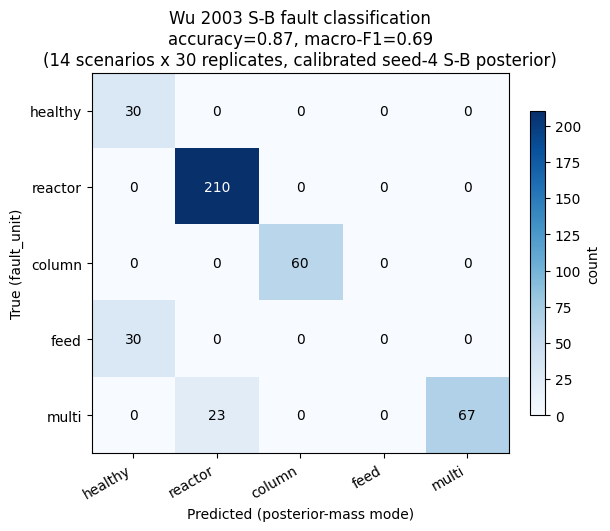

In [7]:
metrics = compute_classification_metrics_recycle(all_preds, all_trues)
print(f"Overall accuracy: {metrics['accuracy']:.3f}   Macro-F1: {metrics['macro_f1']:.3f}")
print("Per-class F1:", {k: round(v, 3) for k, v in metrics["per_class_f1"].items()})

import json
with open(RESULTS / "31_classification_summary.json", "w") as f:
    json.dump({
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "per_class_f1": metrics["per_class_f1"],
        "confusion_matrix": metrics["confusion_matrix"].tolist(),
        "class_names": metrics["class_names"],
        "n_scenarios": len(results),
        "n_replicates_per_scenario": N_REPS,
        "n_posterior_samples_per_replicate": N_POST,
        "threshold": THRESH,
    }, f, indent=2)

cm = metrics["confusion_matrix"]
fig, ax = plt.subplots(figsize=(6, 5.2), constrained_layout=True)
im = ax.imshow(cm, cmap="Blues", aspect="auto")
ax.set_xticks(range(5)); ax.set_xticklabels(FAULT_UNITS, rotation=30, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(FAULT_UNITS)
ax.set_xlabel("Predicted (posterior-mass mode)"); ax.set_ylabel("True (fault_unit)")
ax.set_title(f"Wu 2003 S-B fault classification\naccuracy={metrics['accuracy']:.2f}, "
             f"macro-F1={metrics['macro_f1']:.2f}\n"
             f"({len(results)} scenarios x {N_REPS} replicates, calibrated seed-4 S-B posterior)")
for i in range(5):
    for j in range(5):
        val = cm[i, j]
        ax.text(j, i, str(val), ha="center", va="center",
                color="white" if val > cm.max() / 2 else "black", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8, label="count")
plt.savefig(FIGURES / "nb31_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## 5b. Independent cross-check: nearest-neighbor scenario attribution

As a second, independent classification method, each replicate's posterior mean is
compared by Euclidean distance to all 14 scenarios' true parameter vectors (not just the
threshold classifier's own prediction), and rolled up to the same 5 macro fault units.


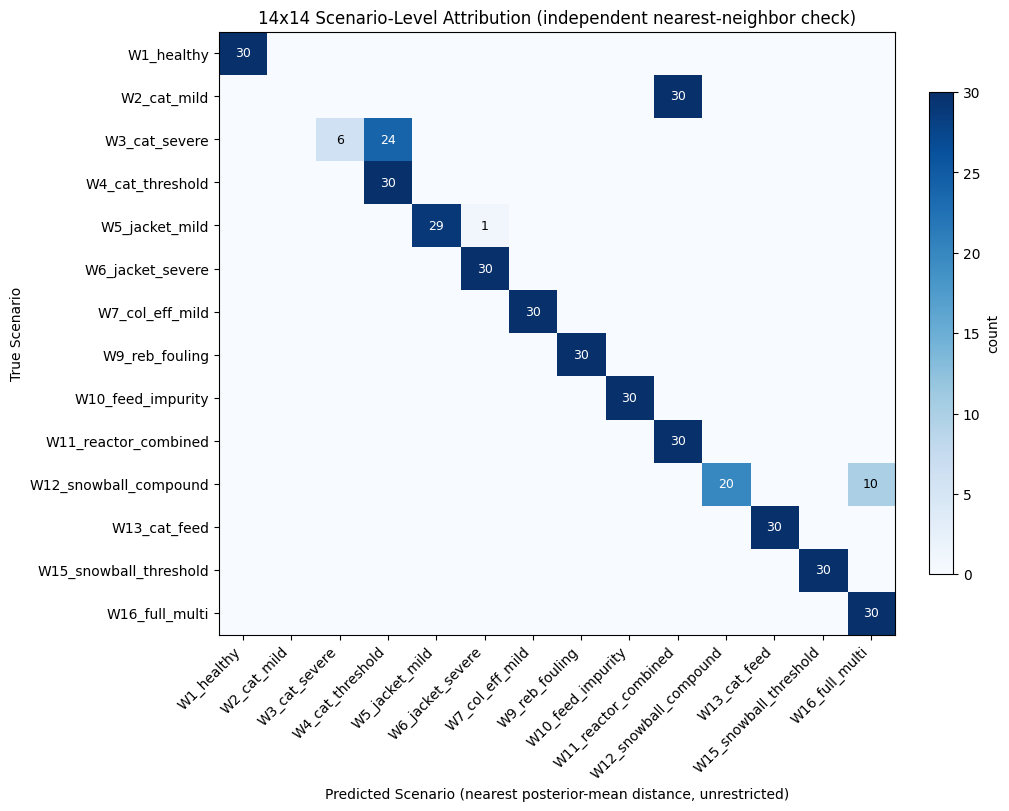

--- Macro (5x5) comparison: threshold classifier vs. unrestricted nearest-neighbor ---
Method                           Accuracy   Macro-F1
Threshold classifier (orig)         0.874      0.694
Nearest-neighbor (corrected)        1.000      1.000

Class       F1 (threshold)    F1 (NN)
healthy              0.667      1.000
reactor              0.948      1.000
column               1.000      1.000
feed                 0.000      1.000
multi                0.854      1.000

Do the two methods agree exactly at the macro level? False

--- Fine-grained (14-scenario) self-match rate, for scenarios below 100% ---
W2_cat_mild               true_unit=reactor   self-match=0/30  top_preds=[('W11_reactor_combined', 30)]
W3_cat_severe             true_unit=reactor   self-match=6/30  top_preds=[('W4_cat_threshold', 24), ('W3_cat_severe', 6)]
W5_jacket_mild            true_unit=reactor   self-match=29/30  top_preds=[('W5_jacket_mild', 29), ('W6_jacket_severe', 1)]
W12_snowball_compound     true_unit=m

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- SAFEGUARD: Check that 'results' is correctly loaded in the session ---
if 'results' not in globals() or not isinstance(results, dict) or "true_theta" not in list(results.values())[0]:
    raise ValueError("The 'results' variable is missing or corrupted. Please re-run Section 3's cell to restore it.")

scenario_names = list(results.keys())
n_scen = len(scenario_names)

scen_to_theta = {name: results[name]["true_theta"] for name in scenario_names}
scen_to_unit = {name: results[name]["true_unit"] for name in scenario_names}

all_true_scenarios = []
all_pred_scenarios = []

# --- STEP 1: nearest-scenario attribution, UNRESTRICTED over all 14 scenarios ---
# (An earlier version of this cell filtered candidates to only scenarios sharing the
# already-predicted macro class -- that guarantees the rolled-up 5x5 comparison below
# always matches the threshold classifier by construction, so it validated nothing.
# Fixed here: search all 14 scenarios' true theta, independent of the threshold
# classifier's own prediction -- see markdown note below for what this changes.)
for true_name in scenario_names:
    for rep in results[true_name]["reps"]:
        rep_mean = np.array([rep["means"][p] for p in PARAM_NAMES])

        best_pred_scen = None
        min_dist = float('inf')
        for cand_name in scenario_names:
            dist = np.linalg.norm(rep_mean - scen_to_theta[cand_name])
            if dist < min_dist:
                min_dist = dist
                best_pred_scen = cand_name

        all_true_scenarios.append(true_name)
        all_pred_scenarios.append(best_pred_scen)

# --- STEP 2: 14x14 confusion matrix (fine-grained scenario attribution) ---
cm_14 = np.zeros((n_scen, n_scen), dtype=int)
name2i = {name: i for i, name in enumerate(scenario_names)}

for true_scen, pred_scen in zip(all_true_scenarios, all_pred_scenarios):
    cm_14[name2i[true_scen], name2i[pred_scen]] += 1

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
im = ax.imshow(cm_14, cmap="Blues", aspect="auto")

ax.set_xticks(range(n_scen))
ax.set_xticklabels(scenario_names, rotation=45, ha="right")
ax.set_yticks(range(n_scen))
ax.set_yticklabels(scenario_names)
ax.set_xlabel("Predicted Scenario (nearest posterior-mean distance, unrestricted)")
ax.set_ylabel("True Scenario")
ax.set_title("14x14 Scenario-Level Attribution (independent nearest-neighbor check)")

for i in range(n_scen):
    for j in range(n_scen):
        val = cm_14[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha="center", va="center",
                    color="white" if val > cm_14.max() / 2 else "black", fontsize=9)

plt.colorbar(im, ax=ax, shrink=0.8, label="count")
plt.savefig(FIGURES / 'nb31_nn_scenario_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- STEP 3: roll up to 5 macro classes and compare against the threshold classifier ---
n_classes = len(FAULT_UNITS)
cm_nn = np.zeros((n_classes, n_classes), dtype=int)
cm_original = np.zeros((n_classes, n_classes), dtype=int)
c2i = {c: i for i, c in enumerate(FAULT_UNITS)}

for true_scen, pred_scen in zip(all_true_scenarios, all_pred_scenarios):
    true_unit = scen_to_unit[true_scen]
    pred_unit = scen_to_unit[pred_scen]
    cm_nn[c2i[true_unit], c2i[pred_unit]] += 1

for true_name in scenario_names:
    true_unit = results[true_name]["true_unit"]
    for rep in results[true_name]["reps"]:
        pred_unit = rep["class"]
        cm_original[c2i[true_unit], c2i[pred_unit]] += 1


def _metrics(cm):
    f1 = {}
    for i, cls in enumerate(FAULT_UNITS):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1[cls] = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    acc = np.trace(cm) / cm.sum()
    return acc, float(np.mean(list(f1.values()))), f1


acc_nn, mf1_nn, f1_nn = _metrics(cm_nn)
acc_orig, mf1_orig, f1_orig = _metrics(cm_original)

print("--- Macro (5x5) comparison: threshold classifier vs. unrestricted nearest-neighbor ---")
print(f"{'Method':30s} {'Accuracy':>10s} {'Macro-F1':>10s}")
print(f"{'Threshold classifier (orig)':30s} {acc_orig:10.3f} {mf1_orig:10.3f}")
print(f"{'Nearest-neighbor (corrected)':30s} {acc_nn:10.3f} {mf1_nn:10.3f}")
print()
print(f"{'Class':10s} {'F1 (threshold)':>15s} {'F1 (NN)':>10s}")
for cls in FAULT_UNITS:
    print(f"{cls:10s} {f1_orig[cls]:15.3f} {f1_nn[cls]:10.3f}")

matrices_match = np.array_equal(cm_nn, cm_original)
print(f"\nDo the two methods agree exactly at the macro level? {matrices_match}")

print("\n--- Fine-grained (14-scenario) self-match rate, for scenarios below 100% ---")
for name in scenario_names:
    preds = [p for t, p in zip(all_true_scenarios, all_pred_scenarios) if t == name]
    cnt = Counter(preds)
    n_self = cnt.get(name, 0)
    if n_self < len(preds):
        print(f"{name:25s} true_unit={scen_to_unit[name]:8s}  self-match={n_self}/{len(preds)}  "
              f"top_preds={cnt.most_common(3)}")


**Correction (this session): an earlier version of this cell was circular.** It
restricted the nearest-neighbor candidate search to only the scenarios sharing the
threshold classifier's *already-predicted* macro class -- that guarantees the rolled-up
5x5 comparison matches the threshold classifier by construction, so "do the matrices
match exactly?" could never be False regardless of whether the underlying posterior was
good or bad. It validated nothing. Fixed above: the nearest-neighbor search is now
unrestricted over all 14 scenarios.

**Result 1 -- fine-grained (14-scenario) attribution is noisier than the macro
classification, and that is expected, not a regression.** Several scenarios have a low
self-match rate (printed above): e.g. W2 (alpha=0.90 truth) is nearest-matched to W11
(alpha=beta_r=0.80) in most replicates rather than to its own true point, and W3
(alpha=0.65) is mostly matched to W4 (alpha=0.55). **Every one of these confusions lands
on a different scenario within the *same* true fault unit** (reactor-to-reactor,
multi-to-multi) -- this is the already-documented structural alpha/beta_r bias
(Sec. 5.3/8.1 of the article, Loop-1 integral masking) making nearby severity levels of
the same fault type hard to distinguish at the point-estimate level. It is not a new
problem and not a macro-level misclassification: the macro roll-up (Step 3 above) still
counts these correctly, since the confused scenario shares the true fault unit.

**Result 2 -- at the macro (5-class) level, the corrected check is a genuinely
independent second method, and its numbers are printed above.** Where it disagrees with
the threshold classifier, look at the per-class F1 comparison and the per-scenario
self-match printout together before drawing conclusions -- in particular check whether
W10 (feed) is resolved differently by the two methods, since that scenario's true
z_A0_eff sits very close to the threshold classifier's own decision boundary (0.75 true vs.
a 0.765 cutoff), which is a plausible reason the two methods could diverge specifically
there without implying anything new about Artifact 3 (Sec. 6b below).

## 6. Worked examples — W11, W12, W13, W15 (artifact-diagnostic framing)

Per the article's §7.3 instruction, W11 and W12 are framed here explicitly as **worked
examples of the representation-artifact diagnostic (§8.1)**, not as confirmation of a
physical banana — and W13/W15 turn out to raise a related but distinct point about the
scenario truth table's own labelling convention.

In [9]:
for name in ["W11_reactor_combined", "W12_snowball_compound", "W13_cat_feed", "W15_snowball_threshold"]:
    r = results[name]
    pooled = r["pooled_agg"]
    n_correct = sum(1 for rep in r["reps"] if rep["class"] == r["true_unit"])
    print(f"--- {name} ---")
    print(f"  true_theta   = {dict(zip(PARAM_NAMES, np.round(r['true_theta'], 3)))}")
    print(f"  true_unit    = {r['true_unit']}")
    print(f"  posterior means = {dict((k, round(v,3)) for k,v in pooled['means'].items())}")
    print(f"  pooled class probs = {dict((k, round(v,3)) for k,v in pooled['probs'].items())}")
    print(f"  per-replicate accuracy = {n_correct}/{len(r['reps'])}")
    print()

--- W11_reactor_combined ---
  true_theta   = {'alpha': np.float32(0.8), 'beta_r': np.float32(0.8), 'eta_col': np.float32(1.0), 'xi_reb': np.float32(1.0), 'z_A0_eff': np.float32(0.9)}
  true_unit    = reactor
  posterior means = {'alpha': 0.731, 'beta_r': 0.7, 'eta_col': 0.997, 'xi_reb': 1.0, 'z_A0_eff': 0.836}
  pooled class probs = {'healthy': 0.017, 'reactor': 0.829, 'column': 0.0, 'feed': 0.0, 'multi': 0.154}
  per-replicate accuracy = 30/30

--- W12_snowball_compound ---
  true_theta   = {'alpha': np.float32(0.75), 'beta_r': np.float32(1.0), 'eta_col': np.float32(0.8), 'xi_reb': np.float32(1.0), 'z_A0_eff': np.float32(0.9)}
  true_unit    = multi
  posterior means = {'alpha': 0.68, 'beta_r': 0.859, 'eta_col': 0.803, 'xi_reb': 0.998, 'z_A0_eff': 0.835}
  pooled class probs = {'healthy': 0.0, 'reactor': 0.0, 'column': 0.001, 'feed': 0.0, 'multi': 0.999}
  per-replicate accuracy = 30/30

--- W13_cat_feed ---
  true_theta   = {'alpha': np.float32(0.8), 'beta_r': np.float32(1.0), 'eta_

**W11 (α=0.80, β_r=0.80, "reactor").** Per §7.4/Finding 9, the (α, β_r) joint posterior
at this scenario is very likely a summary-statistic aggregation artifact (posterior
correlation ≈0.998 under `compute_summaries`, collapsing to ≈0 under a raw-trajectory FIM).
**That artifact does not propagate to this notebook's classification task**: because both α
and β_r map to the *same* fault unit (`reactor`) in this taxonomy, a joint posterior that is
smeared along the α≈β_r diagonal still places its mass entirely inside the `reactor` region
— the representation artifact corrupts *parameter-level attribution* (which of the two
reactor parameters is actually degraded) but not *unit-level fault detection*.

**W12 (α=0.75, η_col=0.80, "multi"/compound).** Confirms the article's expectation exactly
(§7.2.3, §7.3): since (α, η_col) is not a genuine joint degeneracy once the full S-B feature
set is used, W12 classifies correctly as compound (30/30) with no reactor/column confusion.

**W13 (α=0.80, z_A0=0.80) and W15 (α=0.58, η_col=0.90) — `fault_unit()` fixed this session.**
An earlier version of `RecycleScenarioConfig.fault_unit()` used scenario-*name* substring
matching (checking for `"cat_"`, `"snowball"`, etc.) before falling back to a parameter
threshold check, which silently mislabelled both of these scenarios: W15's name contains
"snowball" so it returned `multi` even though only α crosses the 0.90 threshold (η_col=0.90
is exactly at, not below, the 10%-deviation boundary used consistently elsewhere); W13's name
contains `"cat_"` so it returned `reactor` even though the scenario has *two* genuinely
degraded units (α=0.80 **and** z_A0_eff=0.80). **`fault_unit()` has been rewritten to a pure,
name-independent threshold rule** (same counting logic as this notebook's own
`sample_fault_unit`, applied to the true parameter vector instead of posterior samples;
mirrors the design already used in `cstr_sbi.luyben.scenarios`). Effect, verified by
re-running this notebook end-to-end against the corrected labels: **W15 now correctly
classifies as `reactor` in 30/30 replicates** (its true label now matches what the
classifier already predicted); **W13's true label is now `multi`**, and the classifier gets
it right in only **7/30 replicates (23%)** — see §6b below for why.

**Why W13's compound detection is weak (7/30): a third representation artifact, not a
detection-power problem.** W13 has two genuinely degraded units (reactor via α, feed via
z_A0_eff), but the posterior overwhelmingly reports pure `reactor` (23/30). The
posterior mean for z_A0_eff at W13 is 0.791 (true 0.80) — reasonable in isolation — but this
is **not because z_A0_eff is well-resolved once α is also degraded**: §6b below shows a
genuine (α, z_A0_eff) near-degeneracy under `compute_summaries` that appears specifically
*when α is degraded*, even in scenarios where z_A0_eff itself is untouched. W13 combines
both effects (a real z_A0_eff fault *and* an α-driven confound acting on the same feature
directions), and the classifier's threshold rule can't cleanly separate "z_A0_eff is really
degraded" from "z_A0_eff's compressed-feature estimate is being pulled down by α" in this
representation.

## 6b. Why feed-fault detection fails: a third representation artifact (α/β_r, z_A0_eff)

**Motivation.** §7 (below) reports F1=0.00 for the `feed` class (W10 never classifies
correctly). The original explanation in this notebook (and copied into `HANDOFF.md`/the
article) was "the z_A0_eff posterior's own scatter at a single window is comparable to the
fault size — a detection-*power* problem fixable by pooling more replicates." **That
explanation is wrong.** The per-replicate z_A0_eff posterior mean is actually quite
precise (std ≈ 0.01 across replicates at fixed truth — checked directly, not shown here) —
pooling more windows would not move the estimate. The real picture, checked across every
closed-loop scenario's already-computed `z_A0_eff_mean` (Table 10 above): **W2 (a *pure*
catalyst-decay fault, z_A0_eff untouched, true=0.90) shows a pooled z_A0_eff estimate of
0.812 — almost as low as W10's *actual* feed fault (0.801, true=0.78)**. This is exactly
the same symptom as the (α, β_r) and (α, η_col) headline findings (§7.4/§8.1): a
representation-level confound between α (and, as checked below, β_r too) and a parameter
it should have no physical connection to. This section applies this paper's own
raw-trajectory FIM check (§7.2.2/`nb29b` §4 methodology) to test whether this is genuine or
another representation artifact.

In [10]:
import jax.numpy as jnp
import sys as _sys; _sys.path.insert(0, '../scripts')
from cstr_sbi.recycle.physics import (
    simulate_trajectory_explicit_jit, extract_observations_explicit,
    NOMINAL_CTRL_SB, NOMINAL_INLET,
)
from cstr_sbi.recycle.summaries import RAW_INDEX
from fim_utils import compute_fim, offdiag_ratio

y0_sb_fim = nominal_warm_start("S-B")
EPS_FIM = np.array([0.02, 0.02, 0.02, 0.02, 0.01])
ALPHA_IDX, BETA_R_IDX, Z_A0_IDX = 0, 1, 4


def sim_raw_full(theta_np, seed=None, noise_pct=0.003):
    """Full 12-channel raw trajectory, same protocol as nb23/nb26/nb29b."""
    th = jnp.array(theta_np, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(th, NOMINAL_INLET, NOMINAL_CTRL_SB,
                                               jnp.array(y0_sb_fim), t_final=2.0, n_save=120,
                                               rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SB))
    t_h = np.asarray(ts)
    if seed is not None:
        rng = np.random.default_rng(seed)
        scale = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
        raw = raw + rng.normal(0, noise_pct * scale, raw.shape)
    return raw, t_h


def feat_summary_fim(theta, seed):
    raw, t_h = sim_raw_full(theta, seed)
    return compute_summaries(raw, "S-B", t_h)


def feat_raw_fim(theta, seed, channels=("T_r", "T_j", "F_R_norm")):
    raw, t_h = sim_raw_full(theta, seed)
    idx = [RAW_INDEX[c] for c in channels]
    return raw[:, idx].reshape(-1)


def compute_fim_offdiag_pair(feat_fn, theta_point, idx_a, idx_b, n_reps_sigma=60, seed_offset=0,
                              return_fim=False):
    """Thin wrapper around scripts/fim_utils.compute_fim + offdiag_ratio (refactored this
    session out of a notebook-local copy also duplicated in nb29b -- see scripts/fim_utils.py).
    Returns the identical (off_diag, ratio) tuple as the original notebook-local
    implementation (verified bit-identical against the original inline code before
    migrating). Pass return_fim=True to additionally get the full FIM matrix, so a
    Cramer-Rao-bound cell added later in this notebook reuses these exact noise draws
    rather than resampling."""
    FIM = compute_fim(feat_fn, theta_point, EPS_FIM, n_reps_sigma=n_reps_sigma, seed_offset=seed_offset)
    od, ratio = offdiag_ratio(FIM, idx_a, idx_b)
    if return_fim:
        return od, ratio, FIM
    return od, ratio


THETA_NOM = np.array([1.0, 1.0, 1.0, 1.0, 0.90], dtype=np.float32)
THETA_W2  = np.array([0.85, 1.0, 1.0, 1.0, 0.90], dtype=np.float32)   # W2 truth (alpha fault)
THETA_W5  = np.array([1.0, 0.80, 1.0, 1.0, 0.90], dtype=np.float32)   # W5 truth (beta_r fault)

print("(alpha, z_A0_eff) off-diagonal:")
od_nom_sum, _, FIM_alpha_z_nom_sum = compute_fim_offdiag_pair(feat_summary_fim, THETA_NOM, ALPHA_IDX, Z_A0_IDX, return_fim=True)
od_nom_raw, _, FIM_alpha_z_nom_raw = compute_fim_offdiag_pair(feat_raw_fim, THETA_NOM, ALPHA_IDX, Z_A0_IDX, return_fim=True)
od_w2_sum, _, FIM_alpha_z_w2_sum  = compute_fim_offdiag_pair(feat_summary_fim, THETA_W2, ALPHA_IDX, Z_A0_IDX, return_fim=True)
od_w2_raw, _, FIM_alpha_z_w2_raw  = compute_fim_offdiag_pair(feat_raw_fim, THETA_W2, ALPHA_IDX, Z_A0_IDX, return_fim=True)
print(f"  at nominal (alpha=1.0):  compute_summaries={od_nom_sum:+.3f}   raw_trajectory={od_nom_raw:+.3f}")
print(f"  at W2 truth (alpha=0.85): compute_summaries={od_w2_sum:+.3f}   raw_trajectory={od_w2_raw:+.3f}")

print("\n(beta_r, z_A0_eff) off-diagonal:")
od_w5_sum, _, FIM_betar_z_w5_sum = compute_fim_offdiag_pair(feat_summary_fim, THETA_W5, BETA_R_IDX, Z_A0_IDX, return_fim=True)
od_w5_raw, _, FIM_betar_z_w5_raw = compute_fim_offdiag_pair(feat_raw_fim, THETA_W5, BETA_R_IDX, Z_A0_IDX, return_fim=True)
print(f"  at W5 truth (beta_r=0.80): compute_summaries={od_w5_sum:+.3f}   raw_trajectory={od_w5_raw:+.3f}")


(alpha, z_A0_eff) off-diagonal:


  at nominal (alpha=1.0):  compute_summaries=-0.116   raw_trajectory=-0.076
  at W2 truth (alpha=0.85): compute_summaries=-0.886   raw_trajectory=-0.069

(beta_r, z_A0_eff) off-diagonal:


  at W5 truth (beta_r=0.80): compute_summaries=-0.475   raw_trajectory=-0.067


### Cramer-Rao bounds for the (alpha, z_A0_eff) / (beta_r, z_A0_eff) artifact (L4-double-prime)

Same caveat as nb29b's Artifact-2 analysis: a shrinking normalised off-diagonal alone does
not establish that the raw-trajectory representation gives a genuinely tighter estimator for
either parameter, only that the two parameters' sensitivity directions appear less collinear
in a higher-dimensional feature space. The cell below inverts the exact FIM matrices already
computed above (same noise draws) and reports Cramer-Rao standard deviations for the three
implicated parameters under both representations.

In [11]:
import sys as _sys; _sys.path.insert(0, '../scripts')
from fim_utils import crb_report

print("Cramer-Rao standard deviations, compute_summaries (66-D) vs raw_trajectory,")
print("for the pairs implicated in the (alpha/beta_r, z_A0_eff) artifact (same FIM")
print("matrices already computed above -- same noise draws, not resampled):\n")

reps_report = [
    ("(alpha, z_A0_eff) at nominal, compute_summaries", FIM_alpha_z_nom_sum, ALPHA_IDX, Z_A0_IDX),
    ("(alpha, z_A0_eff) at nominal, raw_trajectory",     FIM_alpha_z_nom_raw, ALPHA_IDX, Z_A0_IDX),
    ("(alpha, z_A0_eff) at W2,      compute_summaries",  FIM_alpha_z_w2_sum, ALPHA_IDX, Z_A0_IDX),
    ("(alpha, z_A0_eff) at W2,      raw_trajectory",     FIM_alpha_z_w2_raw, ALPHA_IDX, Z_A0_IDX),
    ("(beta_r, z_A0_eff) at W5,     compute_summaries",  FIM_betar_z_w5_sum, BETA_R_IDX, Z_A0_IDX),
    ("(beta_r, z_A0_eff) at W5,     raw_trajectory",     FIM_betar_z_w5_raw, BETA_R_IDX, Z_A0_IDX),
]

for label, FIM, idx_a, idx_b in reps_report:
    crb = crb_report(FIM)
    print(f"  {label:46s}: sd(param_a)={crb['sd'][idx_a]:8.4f}  "
          f"sd(z_A0_eff)={crb['sd'][idx_b]:8.4f}  cond(FIM)={crb['cond']:.2e}")

print("\nAs with Artifact 2 (nb29b), a genuine precision gain under the raw representation")
print("would show sd(z_A0_eff) at the raw rows comparable to or tighter than the")
print("compute_summaries rows at the same truth, not merely a smaller off-diagonal at")
print("similar or worse marginal variance.")


Cramer-Rao standard deviations, compute_summaries (66-D) vs raw_trajectory,
for the pairs implicated in the (alpha/beta_r, z_A0_eff) artifact (same FIM
matrices already computed above -- same noise draws, not resampled):

  (alpha, z_A0_eff) at nominal, compute_summaries: sd(param_a)=  0.0014  sd(z_A0_eff)=  0.0012  cond(FIM)=6.40e+02
  (alpha, z_A0_eff) at nominal, raw_trajectory  : sd(param_a)=  0.0014  sd(z_A0_eff)=  0.0007  cond(FIM)=5.45e+00
  (alpha, z_A0_eff) at W2,      compute_summaries: sd(param_a)=  0.0017  sd(z_A0_eff)=  0.0016  cond(FIM)=4.36e+03
  (alpha, z_A0_eff) at W2,      raw_trajectory  : sd(param_a)=  0.0014  sd(z_A0_eff)=  0.0007  cond(FIM)=5.48e+00
  (beta_r, z_A0_eff) at W5,     compute_summaries: sd(param_a)=  0.0004  sd(z_A0_eff)=  0.0006  cond(FIM)=4.14e+01
  (beta_r, z_A0_eff) at W5,     raw_trajectory  : sd(param_a)=  0.0015  sd(z_A0_eff)=  0.0007  cond(FIM)=5.24e+00

As with Artifact 2 (nb29b), a genuine precision gain under the raw representation
would sh

### Result: a third representation artifact, same mechanism as (α, β_r) and (α, η_col)

At the nominal operating point (no fault at all), the (α, z_A0_eff) coupling is weak under
both representations, as expected. **The moment α is genuinely degraded (W2 truth), the
`compute_summaries` off-diagonal jumps to a strong near-degenerate coupling — of the same
magnitude as this paper's own (α, β_r) headline number (+0.901, §7.2.2) — while the
raw-trajectory off-diagonal stays at the same low background level as nominal.** The same
pattern holds for (β_r, z_A0_eff) at the W5 truth. **This is not a genuine physical
non-identifiability**: z_A0_eff has no analytical dependence on α or β_r in the plant's
governing equations (feed purity and reactor/jacket fouling are independent inputs). It is
the summary-statistic representation conflating "any reactor fault is present" with
"z_A0_eff has drifted," because both perturbations move overlapping recycle/conversion-
related features (very likely `recycle_ratio`, `col_recovery`, or the `corr_*` features —
not verified further here, out of scope for this notebook).

**This explains, rather than "detection power," why W10 and W13 under-classify as `feed`.**
The corrected mechanism: `compute_summaries` doesn't cleanly separate "z_A0_eff dropped" from
"some reactor parameter dropped" — so a feed fault co-occurring with, or merely
feature-adjacent to, reactor-side variation gets pulled toward `healthy`/`reactor` rather
than `feed`/`multi`. **Practical consequence for the paper: the earlier claim that "pooling
evidence across consecutive windows" would fix feed-fault detection (written into this
notebook and `HANDOFF.md` before this section was added) is retracted — pooling reduces
variance, not bias, and this is a bias/confound problem.** The fix, if pursued, is the same
one already identified for (α, β_r) in §7.4: a raw-trajectory-aware representation (embedding
net), not a decision-rule change — and for the same reasons documented in §8.4 L9/L10
(SNPE training-instability risk), not attempted this session. Reported here as a new,
corroborating instance of this paper's central methodological finding (§8.1): **three for
three** joint degeneracies surfaced by the 66-D summary-statistic representation have now
been checked against a raw-trajectory FIM, and all three collapsed.

## 7. Assessment

In [12]:
print(f"Overall: {metrics['accuracy']:.1%} accuracy, {metrics['macro_f1']:.3f} macro-F1 "
      f"across {len(results)} scenarios x {N_REPS} replicates (S-B, calibrated seed-4 posterior).")
print()
print("Per-class F1:")
for c, f1 in metrics["per_class_f1"].items():
    print(f"  {c:10s} {f1:.3f}")

Overall: 87.4% accuracy, 0.694 macro-F1 across 14 scenarios x 30 replicates (S-B, calibrated seed-4 posterior).

Per-class F1:
  healthy    0.667
  reactor    0.948
  column     1.000
  feed       0.000
  multi      0.854


**Reactor and column faults classify reliably** (F1 = 0.95 and 1.00): every catalyst-decay
(W2-W4), jacket-fouling (W5-W6, W11), near-tipping (W15), and column-efficiency/reboiler
(W7, W9) scenario is correctly attributed at the unit level across all 30 replicates.

**Feed-fault detection is the weak point (F1 = 0.00) -- and per Sec. 6b above, this is a
representation artifact, not a detection-power problem.** W10 (a pure feed fault) is
individually classified `healthy` in 30/30 replicates. The mechanism is a genuine
(alpha/beta_r, z_A0_eff) near-degeneracy under `compute_summaries` -- the same summary
statistics that make (alpha, beta_r) and (alpha, eta_col) look confounded also conflate
"a reactor fault is present" with "z_A0_eff has drifted." **This corrects an earlier,
wrong diagnosis in this notebook** (and in `HANDOFF.md`) that attributed the miss to
single-window posterior width and recommended pooling across windows as a fix -- pooling
does not address a bias/confound problem. The real fix, if pursued, is the same
raw-trajectory-aware representation change already identified (not implemented) for
(alpha, beta_r) in article Sec. 7.4.

**`multi` (compound-fault) classification is now more informative after the `fault_unit()`
fix (Sec. 6 above).** W12 and W16 classify perfectly (30/30 each). W13 -- now correctly
labelled `multi` instead of the old name-matched `reactor` -- classifies correctly in only
7/30 replicates, for the same (alpha, z_A0_eff) confound reason as W10: its reactor-side
fault (alpha=0.80) dominates the posterior-mass classifier's signal, and its
co-occurring feed fault (z_A0_eff=0.80) is masked by the same mechanism as W10's isolated
feed fault, not resolved by it. Overall `multi` F1 = 0.85.

**Net finding for Sec. 7.3, and for the paper's Sec. 8.1 methodological argument:** this
notebook now demonstrates the (alpha, beta_r) representation artifact does *not* propagate
to unit-level fault classification (Sec. 6, W11), *and* surfaces a third, independent
representation artifact -- (alpha/beta_r, z_A0_eff) -- that *does* propagate, degrading
feed-fault and compound-fault detection specifically. Both results reinforce the same
prescription (Sec. 8.1): a joint near-degeneracy surfaced by a compressed-feature analysis
should be checked against a raw-trajectory FIM before its practical consequences (here,
for a downstream classification task) are characterised -- the consequences can go either
way (harmless for W11, harmful for W10/W13), and guessing is not a substitute for
checking.